# 01 — Data Preprocessing & Evaluation Metrics

Before any algorithm can learn something useful, data almost always needs
cleaning, encoding, and scaling. And before we can trust a model's output, we
need metrics that actually reflect what "good" means for the problem at hand.
This notebook covers both halves of that pipeline — the input side and the
output side — since every later module assumes you're comfortable with them.

**In this notebook:**
1. Handling missing values
2. Encoding categorical variables
3. Feature scaling
4. Cross-validation strategies (KFold vs. StratifiedKFold)
5. Regression evaluation metrics
6. Classification evaluation metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(0)

## 1. Handling Missing Values

Most real datasets have gaps. Silently dropping rows can throw away useful
data (or bias the sample); scikit-learn's `SimpleImputer` fills gaps using a
strategy (mean, median, most frequent, or constant).

In [2]:
df = pd.DataFrame({
    "age": [25, 32, np.nan, 45, 29, np.nan, 51],
    "income": [50000, np.nan, 62000, 80000, 54000, 58000, np.nan],
    "city": ["NY", "SF", "NY", np.nan, "LA", "SF", "LA"],
})
df

,age,income,city
0,25.0,50000.0,NY
1,32.0,NaN,SF
2,NaN,62000.0,NY
3,45.0,80000.0,NaN
4,29.0,54000.0,LA
5,NaN,58000.0,SF
6,51.0,NaN,LA


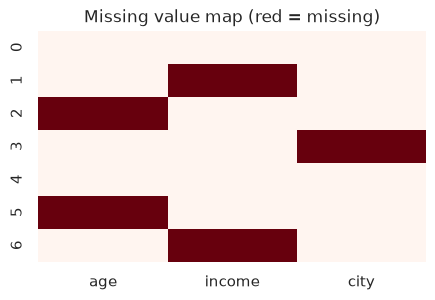

In [3]:
plt.figure(figsize=(5, 3))
sns.heatmap(df.isna(), cbar=False, cmap="Reds")
plt.title("Missing value map (red = missing)")
plt.show()

In [4]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df_imputed = df.copy()
df_imputed[["age", "income"]] = num_imputer.fit_transform(df[["age", "income"]])
df_imputed[["city"]] = cat_imputer.fit_transform(df[["city"]])
df_imputed

,age,income,city
0,25.0,50000.0,NY
1,32.0,58000.0,SF
2,32.0,62000.0,NY
3,45.0,80000.0,LA
4,29.0,54000.0,LA
5,32.0,58000.0,SF
6,51.0,58000.0,LA


`strategy="median"` is usually safer than `"mean"` for numeric columns with
outliers or skew, since the median isn't pulled by extreme values.

## 2. Encoding Categorical Variables

Models need numbers, not strings. Three common encodings:

- **OrdinalEncoder** — maps categories to integers `0, 1, 2, ...`. Only valid when categories have a real order (e.g., "low" < "medium" < "high").
- **OneHotEncoder** — creates one binary column per category. Safe default for nominal (unordered) categories, but can blow up dimensionality with many categories.
- **LabelEncoder** — same idea as OrdinalEncoder but meant for encoding the *target* `y`, not features.

In [5]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

city_col = df_imputed[["city"]]

onehot = OneHotEncoder(sparse_output=False)
onehot_encoded = onehot.fit_transform(city_col)
print("One-hot columns:", onehot.get_feature_names_out())
print(onehot_encoded)

size_order = pd.DataFrame({"size": ["small", "medium", "large", "medium", "small"]})
ordinal = OrdinalEncoder(categories=[["small", "medium", "large"]])
print("\nOrdinal encoding of size:", ordinal.fit_transform(size_order).ravel())

One-hot columns: ['city_LA' 'city_NY' 'city_SF']
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

Ordinal encoding of size: [0. 1. 2. 1. 0.]


## 3. Feature Scaling

Distance-based and gradient-based models (KNN, SVM, logistic/linear
regression, neural nets) are sensitive to feature scale — a feature ranging
0-100,000 will dominate one ranging 0-1 unless we rescale.

- **StandardScaler** — zero mean, unit variance. Good default.
- **MinMaxScaler** — rescales to a fixed range (usually [0, 1]). Useful when you need bounded values.

Tree-based models (Decision Trees, Random Forest, Gradient Boosting) are
scale-invariant and don't need this step.

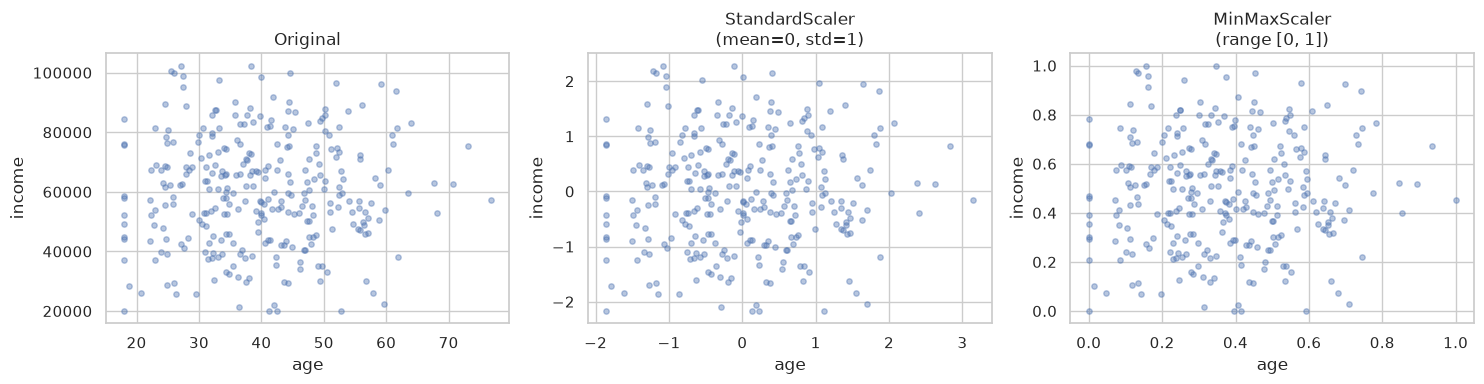

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

raw = pd.DataFrame({
    "age": rng.normal(40, 12, 300).clip(18, 80),
    "income": rng.normal(60000, 20000, 300).clip(20000, 150000),
})

standard_scaled = StandardScaler().fit_transform(raw)
minmax_scaled = MinMaxScaler().fit_transform(raw)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(
    axes,
    [raw.values, standard_scaled, minmax_scaled],
    ["Original", "StandardScaler\n(mean=0, std=1)", "MinMaxScaler\n(range [0, 1])"],
):
    ax.scatter(data[:, 0], data[:, 1], alpha=0.4, s=15)
    ax.set_title(title)
    ax.set_xlabel("age")
    ax.set_ylabel("income")
plt.tight_layout()
plt.show()

Notice the axis ranges change dramatically across the three panels, but the
*relative* shape of the point cloud is identical — scaling doesn't distort
relationships between points, it just changes units.

## 4. Cross-Validation Strategies: KFold vs. StratifiedKFold

For **classification with imbalanced classes**, plain `KFold` can accidentally
create folds with very different class ratios (or even a fold missing a rare
class entirely). `StratifiedKFold` preserves the overall class proportion in
every fold.

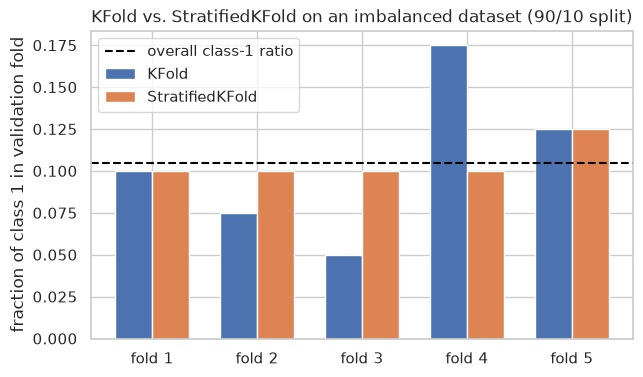

In [7]:
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(
    n_samples=200, n_features=5, weights=[0.9, 0.1], random_state=0
)

kf = KFold(n_splits=5, shuffle=True, random_state=0)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

kf_ratios = [y_imb[val_idx].mean() for _, val_idx in kf.split(X_imb, y_imb)]
skf_ratios = [y_imb[val_idx].mean() for _, val_idx in skf.split(X_imb, y_imb)]

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
x = np.arange(5)
ax.bar(x - width/2, kf_ratios, width, label="KFold")
ax.bar(x + width/2, skf_ratios, width, label="StratifiedKFold")
ax.axhline(y_imb.mean(), color="black", linestyle="--", label="overall class-1 ratio")
ax.set_xticks(x)
ax.set_xticklabels([f"fold {i+1}" for i in range(5)])
ax.set_ylabel("fraction of class 1 in validation fold")
ax.set_title("KFold vs. StratifiedKFold on an imbalanced dataset (90/10 split)")
ax.legend()
plt.show()

`StratifiedKFold` keeps every fold close to the dashed line (the true class
ratio); plain `KFold` can wander noticeably, especially with small data or
rare classes. **Rule of thumb: always use `StratifiedKFold` for
classification**, and plain `KFold` for regression.

## 5. Regression Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | mean of `\|y - ŷ\|` | Average absolute error, same units as target, robust to outliers |
| **MSE** | mean of `(y - ŷ)²` | Penalizes large errors more heavily (squared) |
| **RMSE** | `sqrt(MSE)` | Same units as target, still penalizes large errors |
| **R²** | `1 - SS_res/SS_tot` | Fraction of variance explained; 1.0 = perfect, 0.0 = no better than predicting the mean |

In [8]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=0
)

reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"MSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.3f}")

MAE:  46.174
MSE:  3424.259
RMSE: 58.517
R2:   0.332


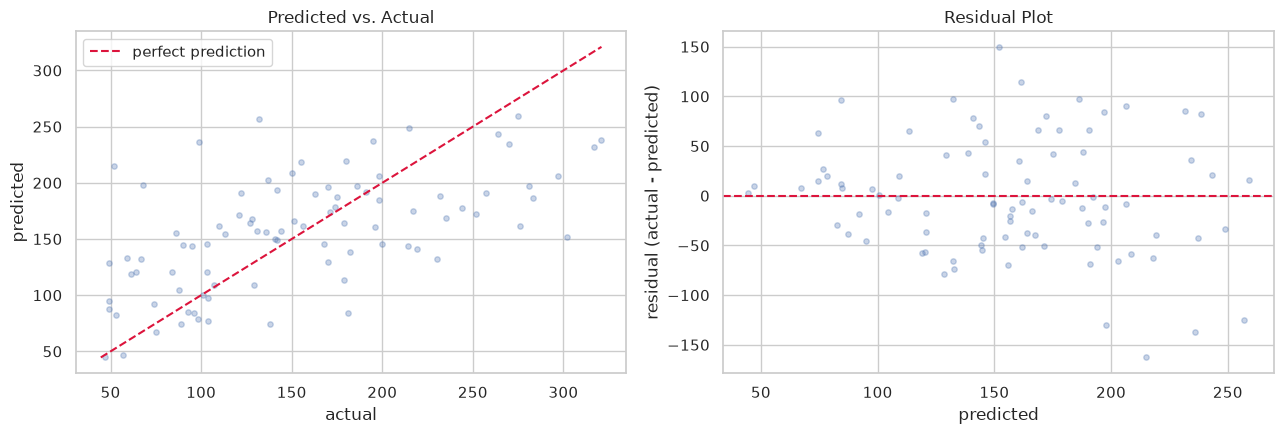

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color="crimson", linestyle="--", label="perfect prediction")
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")
axes[0].set_title("Predicted vs. Actual")
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=15)
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

A good residual plot shows points scattered randomly around the zero line
with no obvious pattern. A funnel shape (variance growing with the predicted
value) or a curve both signal the model is missing structure in the data.

## 6. Classification Evaluation Metrics

| Metric | Formula | When it matters |
|---|---|---|
| **Accuracy** | correct / total | Fine for balanced classes; misleading for imbalanced ones |
| **Precision** | TP / (TP + FP) | Cost of false positives is high (e.g., spam filter) |
| **Recall** | TP / (TP + FN) | Cost of false negatives is high (e.g., disease screening) |
| **F1** | harmonic mean of precision & recall | Single number balancing both |
| **ROC-AUC** | area under the ROC curve | Threshold-independent ranking quality |

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=0, stratify=data.target
)

clf = LogisticRegression(max_iter=5000).fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy:  0.947
Precision: 0.958
Recall:    0.958
F1:        0.958
ROC-AUC:   0.992

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



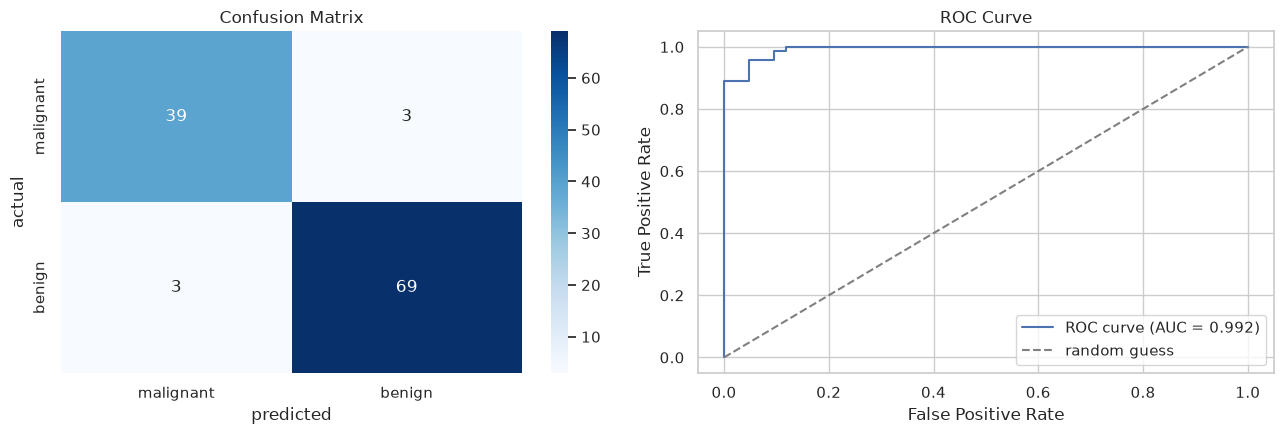

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=data.target_names, yticklabels=data.target_names)
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("actual")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

The confusion matrix breaks accuracy down into the four outcomes precision
and recall are built from; the ROC curve shows how the true-positive vs.
false-positive tradeoff changes as we sweep the classification threshold —
useful when 0.5 isn't necessarily the right cutoff for the business problem.

## Exercises

1. Re-run the missing-value imputation using `strategy="mean"` instead of `"median"` — how much do the imputed values change?
2. Repeat the regression metrics section using `Ridge` instead of `LinearRegression` — does RMSE improve?
3. Lower the classification threshold from 0.5 to 0.3 (`y_proba > 0.3`) and recompute precision/recall — which one moves, and in which direction? Why?

## Key Takeaways

- Clean → encode → scale, roughly in that order, before fitting most models (tree ensembles are the scale-invariant exception).
- Use `StratifiedKFold` for classification, plain `KFold` for regression.
- No single metric tells the whole story — pick the metric(s) that match the cost of the errors you care about.